In [1]:
#importing files from local system
from google.colab import files
upload=files.upload()

Saving Cleaned Dataset.xlsx to Cleaned Dataset.xlsx


In [4]:
##Data can be used for analysis using pandas
import pandas as pd
df=pd.read_excel('Cleaned Dataset.xlsx')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       90 non-null     object 
 1   Customer Name  90 non-null     object 
 2   Product        90 non-null     object 
 3   Sales          90 non-null     float64
 4   Profit         90 non-null     float64
 5   Order Date     90 non-null     object 
dtypes: float64(2), object(4)
memory usage: 4.3+ KB


In [6]:
#statistics of data
df.describe()

,Sales,Profit
count,90.000000,90.000000
mean,27357.954234,5209.608222
std,12834.067241,3466.123454
min,1910.920000,205.590000
25%,16785.372500,2394.325000
50%,27240.975269,4603.600000
75%,38089.640000,7519.195000
max,49029.000000,13753.050000


In [7]:
#Descriptive Statistics
stats = pd.DataFrame({
    "Sum": df['Profit'].sum(),
    "Mean": df['Profit'].mean(),
    "Median": df['Profit'].median(),
    "Mode": df['Profit'].mode()[0],
    "Std Dev": df['Profit'].std(),
    "Variance": df['Profit'].var(),
    "Min": df['Profit'].min(),
    "Max": df['Profit'].max()
}, index=[0])

print(stats)

         Sum         Mean  Median    Mode      Std Dev      Variance     Min  \
0  468864.74  5209.608222  4603.6  205.59  3466.123454  1.201401e+07  205.59   

        Max  
0  13753.05  


In [8]:
stats1= pd.DataFrame({

    "Mean": df['Sales'].mean(),
    "Median": df['Sales'].median(),
    "Mode": df['Sales'].mode()[0],
    "Std Dev": df['Sales'].std(),
    "Variance": df['Sales'].var(),
    "Min": df['Sales'].min(),
    "Max": df['Sales'].max()
}, index=[1])

print(stats1)

           Mean        Median          Mode       Std Dev      Variance  \
1  27357.954234  27240.975269  27267.360538  12834.067241  1.647133e+08   

       Min      Max  
1  1910.92  49029.0  


In [10]:
#count of each product
df["Product"].value_counts()

,count
Product,
Webcam,19
Headphones,15
SSD,13
Mouse,11
Keyboard,11
Monitor,9
Laptop,8
Printer,4


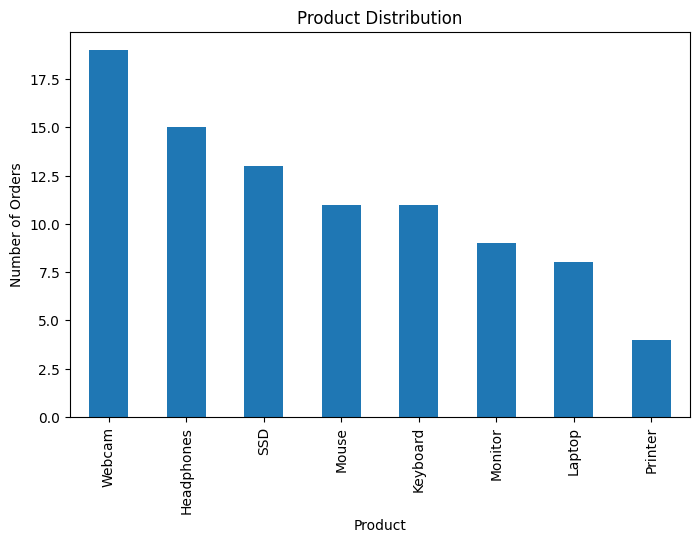

In [11]:
#Product Distribution
import matplotlib.pyplot as plt

product_counts = df["Product"].value_counts()

plt.figure(figsize=(8,5))
product_counts.plot(kind="bar")

plt.title("Product Distribution")
plt.xlabel("Product")
plt.ylabel("Number of Orders")

plt.show()

# Insights
1. Webcam generated the highest revenue.
2. Headphones was the second-highest selling product.
3. Printer contributed the least revenue.
4. Revenue is concentrated among a few products.

In [12]:
#Count of customer names who appears at maximum time
df["Customer Name"].value_counts()

,count
Customer Name,
Rohit,12
Vikram,11
Pooja,11
Sneha,10
Priya,10
Meera,9
Kiran,8
Anjali,7
Aarav,6


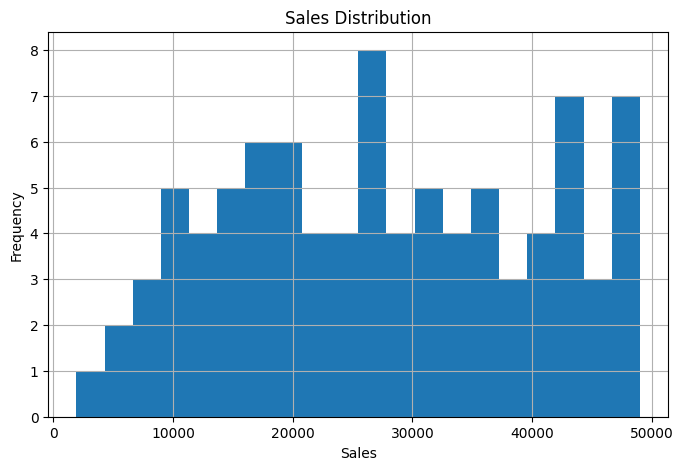

In [13]:
#Univariant Analysis
plt.figure(figsize=(8,5))
df['Sales'].hist(bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

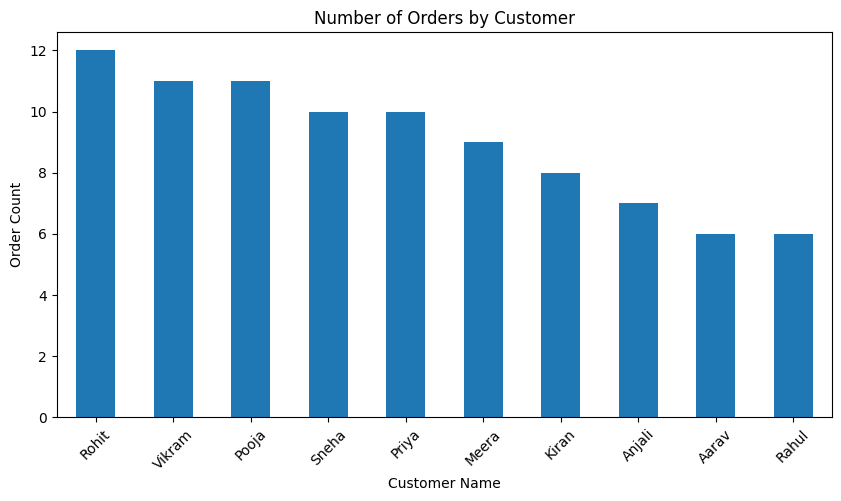

In [14]:
#Cateogorical Analysis
import matplotlib.pyplot as plt

customer_count = df["Customer Name"].value_counts()

plt.figure(figsize=(10,5))
customer_count.plot(kind="bar")

plt.title("Number of Orders by Customer")
plt.xlabel("Customer Name")
plt.ylabel("Order Count")

plt.xticks(rotation=45)

plt.show()

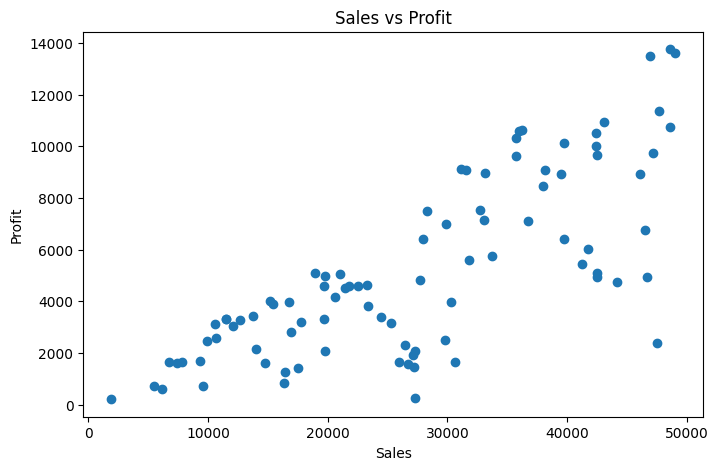

In [15]:
#Scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df['Sales'], df['Profit'])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
plt.show()

In [16]:
#Correlation
df[["Sales","Profit"]].corr()

,Sales,Profit
Sales,1.000000,0.761379
Profit,0.761379,1.000000


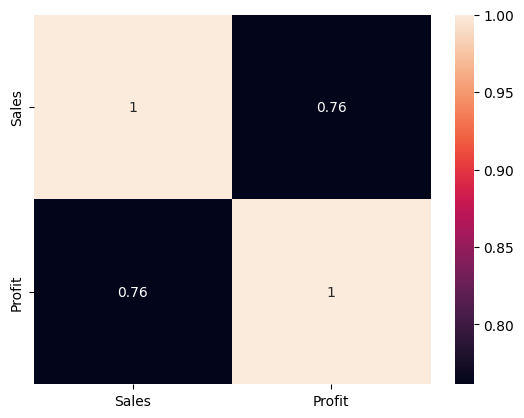

In [17]:
#Heatmap
import seaborn as sns
corr = df[['Sales','Profit']].corr()
sns.heatmap(corr, annot=True)
plt.show()

In [18]:
#Using Sql
import sqlite3
conn = sqlite3.connect("sales.db")

1. A positive relationship exists between Sales and Profit.
2. Higher sales generally lead to higher profits.
3. No major outliers were observed.

In [19]:
df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

90

In [20]:
#Query1
query = """
SELECT Product,
SUM(Sales) AS Revenue
FROM sales
GROUP BY Product
ORDER BY Revenue DESC
LIMIT 5
"""

pd.read_sql(query, conn)

,Product,Revenue
0,Webcam,517070.300538
1,Headphones,400160.820000
2,SSD,382114.420000
3,Mouse,327650.110000
4,Laptop,306992.350000


In [21]:
#Query2
query = """
SELECT COUNT(*) AS TotalOrders
FROM sales
"""

pd.read_sql(query, conn)

,TotalOrders
0,90


In [22]:
#Query3
query = """
SELECT Product,
SUM(Profit) AS TotalProfit
FROM sales
GROUP BY Product
ORDER BY TotalProfit DESC
"""
pd.read_sql(query, conn)

,Product,TotalProfit
0,Webcam,88082.39
1,SSD,85417.82
2,Headphones,66004.21
3,Laptop,65343.05
4,Mouse,58084.99
5,Monitor,49703.97
6,Keyboard,45529.95
7,Printer,10698.36


In [23]:
#Query4
query="""SELECT [Customer Name],
SUM(Sales) AS TotalSales
FROM sales
GROUP BY [Customer Name]
ORDER BY TotalSales DESC
"""
pd.read_sql(query, conn)

,Customer Name,TotalSales
0,Rohit,303606.920538
1,Priya,299084.360000
2,Kiran,281994.620538
3,Pooja,276533.420000
4,Meera,262043.660000
5,Anjali,254687.530000
6,Sneha,232626.530000
7,Vikram,223981.710000
8,Aarav,201452.900000
9,Rahul,126204.230000


In [24]:
#Query5
query="""SELECT AVG(Sales)
FROM sales
"""
pd.read_sql(query, conn)

,AVG(Sales)
0,27357.954234
